## Предсказание наличия сердечно-сосудистых заболеваний (ССЗ)


В данном проекте используется датасет из соревнования “TECH WEEKEND Data Science Hackathon [BITS Goa Only]”, 
посвящённого задаче предсказания наличия сердечно-сосудистых заболеваний на основе медицинских данных.

Источник данных: [https://www.kaggle.com/competitions/tech-weekend-data-science-hackathon/data]

***Описание признаков*** ---

**ID** (уникальный идентификатор пациента)

**age** (возраст пациента)

**sex** (пол пациента, обычно: 0 — женщина, 1 — мужчина)

**chest** (тип боли в груди, 4 категории; клинически различают типы стенокардии)

**resting_blood_pressure** (артериальное давление в покое, мм рт. ст.)

**serum_cholestoral** (уровень холестерина в крови, мг/дл)

**fasting_blood_sugar** (уровень глюкозы натощак: > 120 мг/дл — 1, иначе 0)

**resting_electrocardiographic_results** (результаты ЭКГ в покое, категории 0–2)

**maximum_heart_rate_achieved** (максимальная достигнутая частота сердечных сокращений)

**exercise_induced_angina** (стенокардия, вызванная физической нагрузкой: 1 — да, 0 — нет)

**oldpeak** (депрессия ST-сегмента, вызванная нагрузкой относительно состояния покоя)

**slope** (наклон пикового сегмента ST при нагрузке)

**number_of_major_vessels** (количество крупных сосудов (0–3), окрашенных при флюороскопии)

**thal** (результат теста: 3 — норма, 6 — фиксированный дефект, 7 — обратимый дефект)

**class** (целевая переменная: наличие заболевания сердца — 1, отсутствие — 0)

## Обработка данных

***Описание набора данных***

Тренировочный набор данных (Train Dataset) состоит из 600000 строк и 15 колонок

Тестовый набор данных (Test Dataset) состоит из  400000 строк и  14 колонок

## Тренировочный набор данных (train set)

**Загрузка тренировочного набора данных и основная информация о признаках**

In [1]:
# загрузка библиотек
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

df_train = pd.read_csv('DATA/train.csv')

#  названия колонок
df_train.columns

Index(['ID', 'age', 'sex', 'chest', 'resting_blood_pressure',
       'serum_cholestoral', 'fasting_blood_sugar',
       'resting_electrocardiographic_results', 'maximum_heart_rate_achieved',
       'exercise_induced_angina', 'oldpeak', 'slope',
       'number_of_major_vessels', 'thal', 'class'],
      dtype='object')

In [2]:
df_train.head(10).T


,0,1,2,3,4,5,6,7,8,9
ID,0.000000,1.000000,2.000000,3.000000,4.000000,5.000000,6.000000,7.000000,8.000000,9.000000
age,49.207124,53.628425,49.591426,58.991445,51.053602,61.069909,43.108527,47.204068,55.158454,49.569574
sex,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000
chest,4.000000,1.741596,4.000000,4.000000,1.954609,3.000000,4.000000,4.000000,4.000000,1.727698
resting_blood_pressure,162.996167,130.233730,146.999012,112.369143,138.032047,117.285359,121.156172,126.261227,164.940705,128.751300
serum_cholestoral,181.108682,276.474630,223.300517,187.245501,238.482868,233.973393,210.307425,215.958580,189.464297,239.304733
fasting_blood_sugar,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
resting_electrocardiographic_results,0.000000,2.000000,2.000000,0.000000,0.000000,0.000000,2.000000,2.000000,2.000000,2.000000
maximum_heart_rate_achieved,148.227858,152.917139,102.352090,158.164750,172.540828,112.820336,154.180680,163.239001,102.672796,158.839407
exercise_induced_angina,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000


In [3]:
print(df_train.shape)
print(df_train.info())

(600000, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600000 entries, 0 to 599999
Data columns (total 15 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   ID                                    600000 non-null  int64  
 1   age                                   600000 non-null  float64
 2   sex                                   600000 non-null  int64  
 3   chest                                 600000 non-null  float64
 4   resting_blood_pressure                600000 non-null  float64
 5   serum_cholestoral                     600000 non-null  float64
 6   fasting_blood_sugar                   600000 non-null  int64  
 7   resting_electrocardiographic_results  600000 non-null  int64  
 8   maximum_heart_rate_achieved           600000 non-null  float64
 9   exercise_induced_angina               600000 non-null  int64  
 10  oldpeak                               600000 non-null  

Дата сет ( тренировочная часть) содержит 600000 строк и 15 колонок. Ни одна из колонок не содержит пропусков. Все данные представлены числовыми значениями

In [4]:
df_train['class'].value_counts()
df_train['class'].value_counts(normalize=True)


class
0    0.555815
1    0.444185
Name: proportion, dtype: float64

В тренировочной выборке классы распределены относительно равномерно, с небольшим преобладанием класса 0.

**Статистики тренировочного набора**

In [5]:
df_train.describe(include='all').round(2).T

,count,mean,std,min,25%,50%,75%,max
ID,600000.0,299999.50,173205.23,0.00,149999.75,299999.50,449999.25,599999.00
age,600000.0,54.43,9.09,26.06,48.08,55.13,60.66,79.59
sex,600000.0,0.68,0.47,0.00,0.00,1.00,1.00,1.00
chest,600000.0,3.17,0.95,-0.54,3.00,3.00,4.00,4.00
resting_blood_pressure,600000.0,131.34,17.84,82.92,119.92,129.73,139.92,209.67
serum_cholestoral,600000.0,249.59,51.70,98.33,216.48,244.23,274.35,527.76
fasting_blood_sugar,600000.0,0.15,0.36,0.00,0.00,0.00,0.00,1.00
resting_electrocardiographic_results,600000.0,1.02,0.99,0.00,0.00,2.00,2.00,2.00
maximum_heart_rate_achieved,600000.0,149.59,23.07,61.84,135.70,153.22,165.17,208.74
exercise_induced_angina,600000.0,0.33,0.47,0.00,0.00,0.00,1.00,1.00


In [6]:
df_train.min()

ID                                       0.000000
age                                     26.061695
sex                                      0.000000
chest                                   -0.538498
resting_blood_pressure                  82.918527
serum_cholestoral                       98.326263
fasting_blood_sugar                      0.000000
resting_electrocardiographic_results     0.000000
maximum_heart_rate_achieved             61.844168
exercise_induced_angina                  0.000000
oldpeak                                 -0.806788
slope                                    1.000000
number_of_major_vessels                  0.000000
thal                                     3.000000
class                                    0.000000
dtype: float64

В ходе первичного анализа распределений признаков были обнаружены отрицательные значения в переменной oldpeak, что допустимо, так как данный признак отражает отклонение сегмента ST относительно состояния покоя и может принимать как положительные, так и отрицательные значения.

Также на раннем этапе были выявлены отрицательные значения в признаке chest. После проверки данный признак будет приведён к корректному формату.

Остальные признаки имеют значения, соответствующие их физическому и медицинскому смыслу (например, давление, холестерин, частота сердечных сокращений не содержат отрицательных значений), что подтверждает общее качество данных.

**Количество пропущенных значений и дупликатов**

In [7]:
print(df_train.isna().sum())
print(df_train.duplicated().sum())

ID                                      0
age                                     0
sex                                     0
chest                                   0
resting_blood_pressure                  0
serum_cholestoral                       0
fasting_blood_sugar                     0
resting_electrocardiographic_results    0
maximum_heart_rate_achieved             0
exercise_induced_angina                 0
oldpeak                                 0
slope                                   0
number_of_major_vessels                 0
thal                                    0
class                                   0
dtype: int64
0


Данный набор не содержит пропусков и дубликатов

**Количество уникальных значений по признакам**

In [8]:
df_train.nunique()

ID                                      600000
age                                     594106
sex                                          2
chest                                   133009
resting_blood_pressure                  596241
serum_cholestoral                       598797
fasting_blood_sugar                          2
resting_electrocardiographic_results         3
maximum_heart_rate_achieved             597583
exercise_induced_angina                      2
oldpeak                                 384255
slope                                        3
number_of_major_vessels                      4
thal                                         3
class                                        2
dtype: int64

Набор данных содержит бинарные, категориальные и другие числовые признаки.

**Бинарные признаки** --- **sex, fasting_blood_sugar, exercise_induced_angina**. Признак class (target)  также бинарныйй 



**Категориальные признаки**

**number_of_major_vessels, thal, chest, resting_electrocardiographic_results** - относятся, судя по описанию, к категориальным признакам

In [9]:
df_train[["number_of_major_vessels", "thal", "chest", "resting_electrocardiographic_results", "slope"]].nunique()

number_of_major_vessels                      4
thal                                         3
chest                                   133009
resting_electrocardiographic_results         3
slope                                        3
dtype: int64

In [10]:
df_train[["number_of_major_vessels", "thal", "chest", "resting_electrocardiographic_results", "slope"]].head(15).T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
number_of_major_vessels,0.0,0.000000,2.0,1.0,1.000000,0.0,0.0,0.0,2.0,0.000000,0.0,0.0,3.0,0.0,0.0
thal,3.0,3.000000,7.0,7.0,3.000000,3.0,7.0,3.0,7.0,3.000000,3.0,3.0,3.0,3.0,3.0
chest,4.0,1.741596,4.0,4.0,1.954609,3.0,4.0,4.0,4.0,1.727698,3.0,3.0,4.0,3.0,3.0
resting_electrocardiographic_results,0.0,2.000000,2.0,0.0,0.000000,0.0,2.0,2.0,2.0,2.000000,0.0,0.0,2.0,2.0,2.0
slope,2.0,2.000000,2.0,1.0,1.000000,1.0,1.0,1.0,2.0,2.000000,1.0,2.0,2.0,1.0,1.0


Признак **chest** по описанию является категориальным (4 значения), однако в данных обнаружены дробные значения. Основная масса наблюдений из класса 3 и 4 соответствует целочисленным категориям, а дробные значения (133 009 значений) встречаются исключительно среди значений, которые должны были бы быть классом 1 или 2. 

In [11]:
df_train['chest'].value_counts()
df_train['chest'].value_counts(normalize=True)


chest
4.000000    0.475573
3.000000    0.293622
1.870508    0.000007
1.782514    0.000007
1.945328    0.000007
              ...   
2.321349    0.000002
2.481316    0.000002
1.603047    0.000002
1.341366    0.000002
1.836168    0.000002
Name: proportion, Length: 133009, dtype: float64

In [12]:
#  статистики признака chest

df_train['chest'].describe()

count    600000.000000
mean          3.170247
std           0.949618
min          -0.538498
25%           3.000000
50%           3.000000
75%           4.000000
max           4.000000
Name: chest, dtype: float64

в данных также содержатся отрицательные значения, что противоречит медицинскому смыслу данных ( классификация боли не может быть отрицательным признаком) 

In [13]:
df_train['chest'].value_counts().head(10)

chest
4.000000    285344
3.000000    176173
1.870508         4
1.782514         4
1.945328         4
1.590429         4
1.730036         4
1.639221         4
1.253734         3
1.835079         3
Name: count, dtype: int64

Посмотрим на распределение значений по категориям, а также возможные выбросы

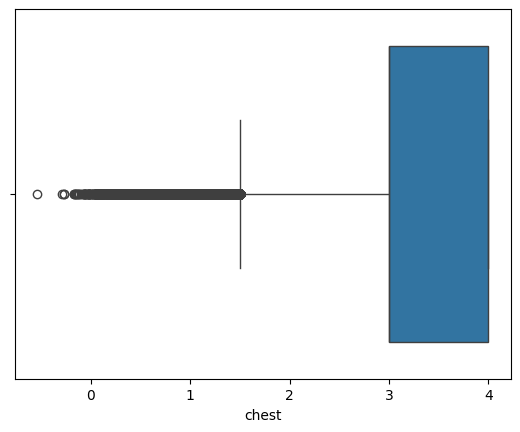

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df_train['chest'])
plt.show()

In [15]:
(df_train['chest'] < 1).sum()

np.int64(10392)

Доля значений ниже допустимого диапазона (менее 1) довольна значительна. Удаление строк не производилось, чтобы избежать потери данных; вместо этого признак был приведён к корректному диапазону путём округления и ограничения значений в интервале [1, 4], с последующим преобразованием к целочисленному типу.

In [16]:
df_train['chest'] = df_train['chest'].round().clip(1, 4).astype(int)

In [17]:
df_train['chest'].value_counts().head(10)

chest
4    285350
3    181797
2     83989
1     48864
Name: count, dtype: int64

Теперь признак приведен к категориальному типу. Доля признаков класса 1 и 2 заметно меньше, чем 3 или 4.

In [18]:
df_train['chest'].value_counts(normalize=True)

chest
4    0.475583
3    0.302995
2    0.139982
1    0.081440
Name: proportion, dtype: float64

**Визуализация распределение признака по категориям**

<Axes: xlabel='chest', ylabel='count'>

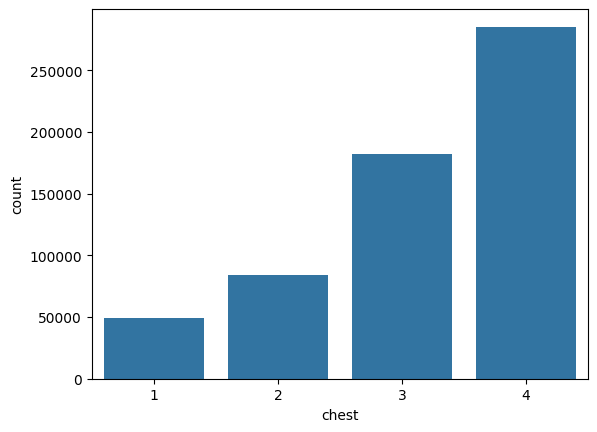

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='chest', data=df_train)

Посмготрим на распределение категорий признака chest  по классам (0  и 1) целевой переменной

In [20]:
pd.crosstab(df_train['chest'], df_train['class'], normalize='index')

class,0,1
chest,,
1,0.800978,0.199022
2,0.802819,0.197181
3,0.781157,0.218843
4,0.297564,0.702436


Анализ распределения признака chest по классам показывает, что для категории 4 доля наблюдений с целевым классом 1 существенно выше по сравнению с другими категориями.

Это свидетельствует о наличии связи между типом боли в груди и наличием заболевания сердца.

Теперь посмотрим на распределение других признаков в зависимости от target

In [21]:
df_train.groupby('class').mean().T

class,0,1
ID,300052.991760,299932.565001
age,52.622820,56.682537
sex,0.555008,0.830656
chest,2.817697,3.616969
resting_blood_pressure,129.505483,133.636649
serum_cholestoral,244.149621,256.403072
fasting_blood_sugar,0.155846,0.144388
resting_electrocardiographic_results,0.860082,1.220441
maximum_heart_rate_achieved,157.198078,140.074562
exercise_induced_angina,0.160272,0.550266


При анализе средних значений признаков в разрезе целевой переменной выявлены признаки с выраженной разделяющей способностью.

Наиболее значимые различия наблюдаются для переменных:

oldpeak (1.55 vs 0.65),

number_of_major_vessels (1.16 vs 0.30),

thal (5.83 vs 3.82),

exercise_induced_angina (0.55 vs 0.16),

что указывает на их потенциальную важность для модели.

Также отмечается снижение maximum_heart_rate у пациентов с заболеванием, что соответствует клинической логике.

В то же время признаки, такие как fasting_blood_sugar, демонстрируют слабые различия между классами и, вероятно, будут иметь низкую предсказательную ценность.

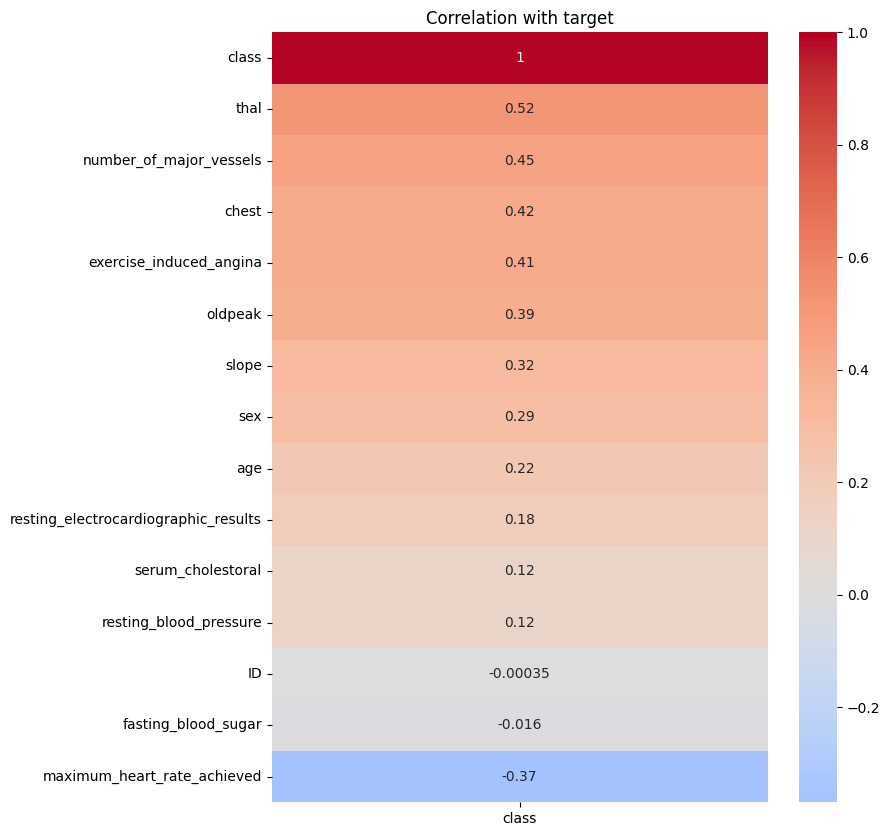

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df_train.corr(numeric_only=True)

plt.figure(figsize=(8, 10))
sns.heatmap(corr[['class']].sort_values(by='class', ascending=False),
            annot=True, cmap='coolwarm', center=0)
plt.title('Correlation with target')
plt.show()

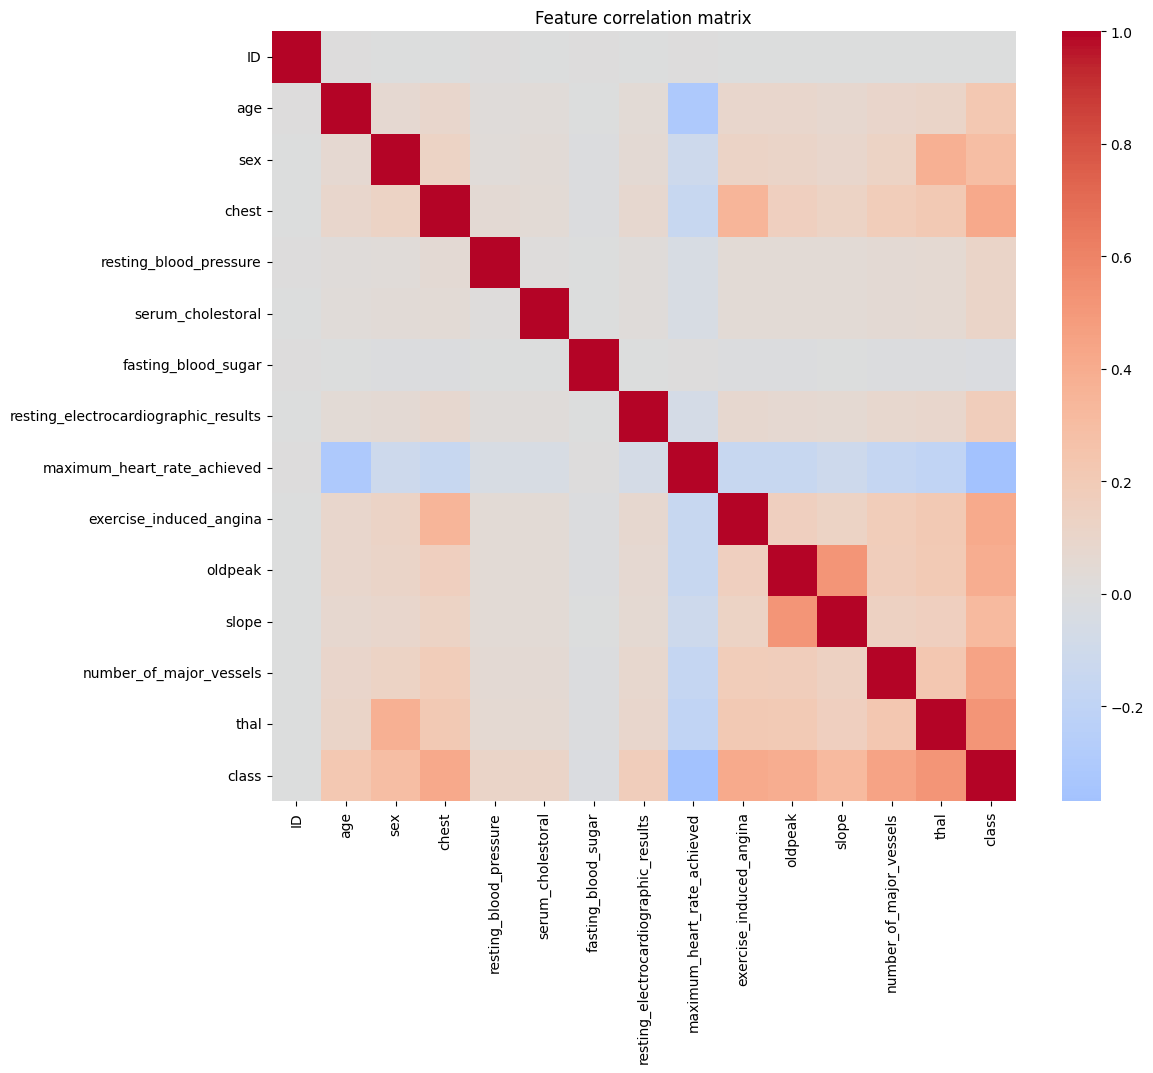

In [23]:
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Feature correlation matrix')
plt.show()

Корреляционный анализ подтвердил ранее выявленные зависимости между признаками и целевой переменной.

Наибольшую положительную корреляцию с наличием заболевания демонстрируют признаки thal, number_of_major_vessels, chest, exercise_induced_angina и oldpeak, что указывает на их высокую информативность.

Отрицательная корреляция наблюдается для maximum_heart_rate, что согласуется с клинической интерпретацией снижения функциональной способности сердца.

Анализ полной матрицы корреляций показал отсутствие выраженной мультиколлинеарности, однако наблюдаются умеренные взаимосвязи между признаками, отражающими схожие физиологические процессы (например, oldpeak и slope).

**Диаграмма рассеивания зависимости числовых признаков от целевой переменной**

Для дополнительного анализа взаимосвязей между признаками были построены диаграммы рассеяния, позволяющие оценить характер зависимости между ними и выявить возможные новые закономерности.

***maximum_heart_rate_achieved, oldpeak*** и целевой показатель

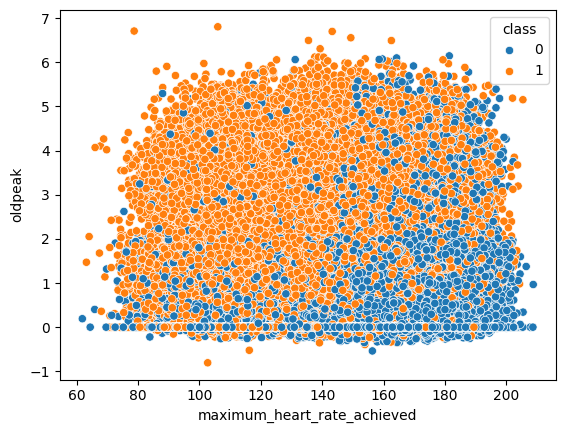

In [24]:
sns.scatterplot(x='maximum_heart_rate_achieved', y='oldpeak', hue='class', data=df_train)
plt.show()

Диаграмма рассеивания не выявляет выраженной линейной зависимости между признаками, однако наблюдается тенденция: при увеличении значения oldpeak возрастает доля наблюдений с целевым классом 1, тогда как более высокие значения maximum_heart_rate_achieved чаще соответствуют классу 0. При этом классы существенно перекрываются.

***age, maximum_heart_rate_achieved*** и целевой показатель

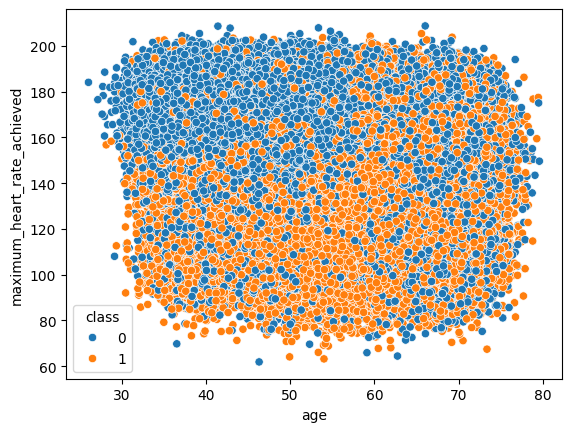

In [25]:
sns.scatterplot(x='age', y='maximum_heart_rate_achieved', hue='class', data=df_train)
plt.show()

Наблюдается отрицательная зависимость между возрастом (age) и максимальной достигнутой частотой сердечных сокращений (maximum_heart_rate_achieved): с увеличением возраста значения максимальной ЧСС снижаются, что соответствует физиологической норме.При этом классы так же существенно перекрываются.


***age, oldpeak*** и целевой показатель

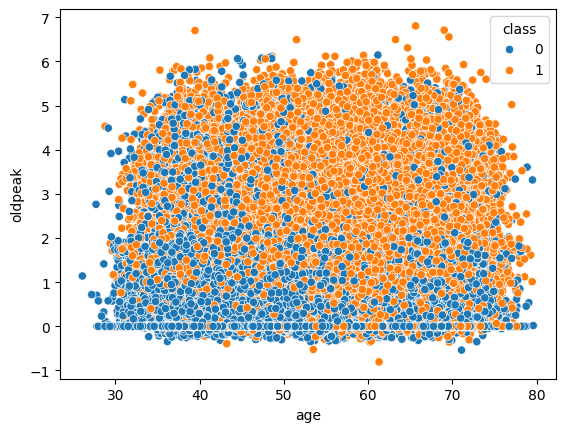

In [26]:
sns.scatterplot(x='age', y='oldpeak', hue='class', data=df_train)
plt.show()


Диаграмма рассеивания показывает, что признак oldpeak связан с целевой переменной:  при низких значениях преобладает класс 0, тогда как при увеличении значения возрастает доля класса 1. При этом признак age не обеспечивает выраженного разделения, и классы остаются существенно перекрывающимися.

Построенные диаграммы рассеивания подтверждают ранее выявленные зависимости между признаками и целевой переменной, дополнительных закономерностей не обнаружено.

**Анализ взаимодействия наиболее информативных признаков**

Дополнительно был проведён анализ взаимодействия наиболее информативных признаков. Признак oldpeak сохраняет различия между классами внутри различных категорий признаков thal и exercise_induced_angina. 

<Axes: xlabel='thal', ylabel='oldpeak'>

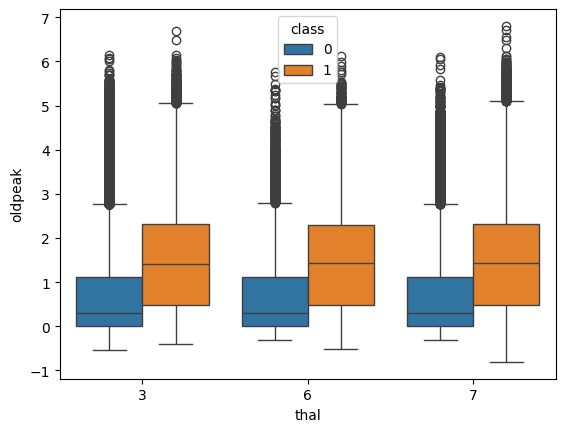

In [27]:
sns.boxplot(x='thal', y='oldpeak', hue='class', data=df_train)

<Axes: xlabel='exercise_induced_angina', ylabel='oldpeak'>

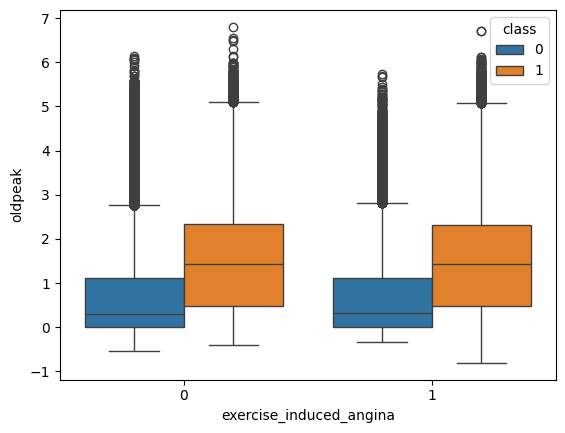

In [28]:
sns.boxplot(x='exercise_induced_angina', y='oldpeak', hue='class', data=df_train)

Кроме того, анализ сочетаний категориальных признаков (thal и number_of_major_vessels) выявил структурные зависимости между ними: с увеличением значений thal возрастает доля пациентов с бОльшим числом поражённых сосудов.

In [29]:
pd.crosstab(df_train['thal'], df_train['number_of_major_vessels'], normalize='index')

number_of_major_vessels,0,1,2,3
thal,,,,
3,0.693617,0.173795,0.084868,0.047719
6,0.531966,0.235257,0.145659,0.087118
7,0.444688,0.271796,0.174786,0.108730


В целом наблюдается, что комбинации признаков усиливают различия между классами.

**Статистики числовых показателей**

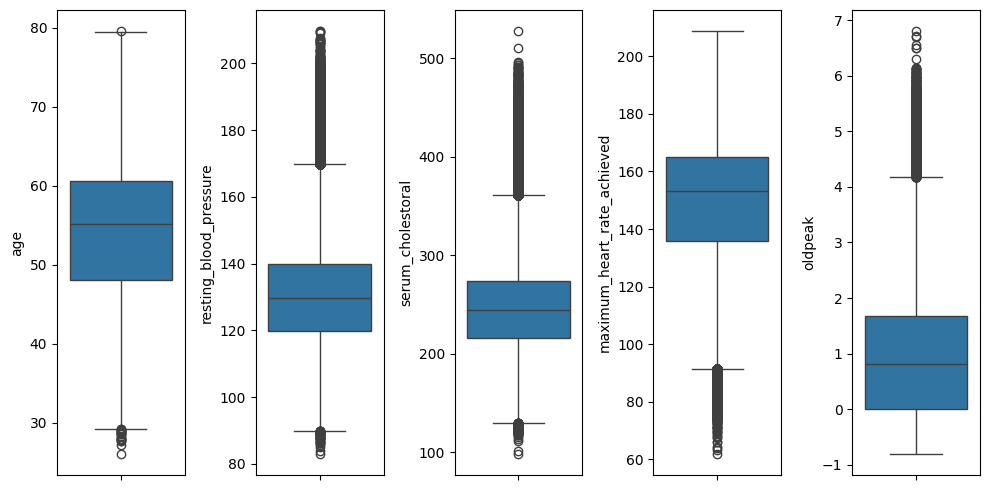

In [30]:
col_num = ['age', 'resting_blood_pressure', 'serum_cholestoral', 'maximum_heart_rate_achieved', 'oldpeak']
plt.figure(figsize=(10,5))
for i in range(0,len(col_num)):
    plt.subplot(1,len(col_num),i+1)
    sns.boxplot(y=df_train[col_num[i]])
    plt.tight_layout()

Несмотря на наличие выбросов, значения находятся в допустимых диапазонах и могут отражать реальные клинические случаи, поэтому удаление выбросов не проводилось.

**Удаление ***ID*** и ***fasting_blood_sugar*****

На основе корреляционного анализа и сравнения распределений было принято решение исключить признаки ID и fasting_blood_sugar, так как они не демонстрируют значимой связи с целевой переменной и не несут полезной информации для модели.

In [31]:
cols_to_drop = ['ID', 'fasting_blood_sugar']
df_train = df_train.drop(columns=cols_to_drop)

In [32]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600000 entries, 0 to 599999
Data columns (total 13 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   age                                   600000 non-null  float64
 1   sex                                   600000 non-null  int64  
 2   chest                                 600000 non-null  int64  
 3   resting_blood_pressure                600000 non-null  float64
 4   serum_cholestoral                     600000 non-null  float64
 5   resting_electrocardiographic_results  600000 non-null  int64  
 6   maximum_heart_rate_achieved           600000 non-null  float64
 7   exercise_induced_angina               600000 non-null  int64  
 8   oldpeak                               600000 non-null  float64
 9   slope                                 600000 non-null  int64  
 10  number_of_major_vessels               600000 non-null  int64  
 11  

In [33]:
summary = pd.DataFrame({
    'dtype': df_train.dtypes,
    'n_unique': df_train.nunique(),
    'min': df_train.min(),
    'max': df_train.max()
})

summary

,dtype,n_unique,min,max
age,float64,594106,26.061695,79.591647
sex,int64,2,0.000000,1.000000
chest,int64,4,1.000000,4.000000
resting_blood_pressure,float64,596241,82.918527,209.673650
serum_cholestoral,float64,598797,98.326263,527.755764
resting_electrocardiographic_results,int64,3,0.000000,2.000000
maximum_heart_rate_achieved,float64,597583,61.844168,208.735196
exercise_induced_angina,int64,2,0.000000,1.000000
oldpeak,float64,384255,-0.806788,6.803372
slope,int64,3,1.000000,3.000000


**Кодирование категориальных признаков**

Для окончательного формирование конечного набора данных, пригодного для построения моделей, необходимо закодировать категориальные признаки - ***chest, resting_electrocardiographic_results, slope, number_of_major_vessels, thal***

Признак ***number_of_major_vessels*** представляет собой количество поражённых сосудов (значения 0–3), имеет естественный порядок и количественную интерпретацию. В отличие от номинальных категориальных признаков, увеличение значения отражает усиление выраженности состояния.
В связи с этим признак не был закодирован с помощью one-hot encoding и оставлен в исходном числовом виде.
Остальные категориальнеы признаки были закодированы при помощи one-hot кодирования. 

In [34]:
# категориальные признаки
cat_cols = [
    'chest',
    'resting_electrocardiographic_results',
    'slope',
    'thal'
]
# кодирование one-hot
df_train = pd.get_dummies(df_train, columns=cat_cols, drop_first=True)


In [35]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600000 entries, 0 to 599999
Data columns (total 18 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   age                                     600000 non-null  float64
 1   sex                                     600000 non-null  int64  
 2   resting_blood_pressure                  600000 non-null  float64
 3   serum_cholestoral                       600000 non-null  float64
 4   maximum_heart_rate_achieved             600000 non-null  float64
 5   exercise_induced_angina                 600000 non-null  int64  
 6   oldpeak                                 600000 non-null  float64
 7   number_of_major_vessels                 600000 non-null  int64  
 8   class                                   600000 non-null  int64  
 9   chest_2                                 600000 non-null  bool   
 10  chest_3                                 6000

Для унификации формата dummy-признаки были преобразованы в целочисленный тип (0/1).

In [36]:
cols = df_train.filter(regex='chest|resting_electrocardiographic_results|slope|thal').columns

df_train[cols] = df_train[cols].astype(int)

In [37]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600000 entries, 0 to 599999
Data columns (total 18 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   age                                     600000 non-null  float64
 1   sex                                     600000 non-null  int64  
 2   resting_blood_pressure                  600000 non-null  float64
 3   serum_cholestoral                       600000 non-null  float64
 4   maximum_heart_rate_achieved             600000 non-null  float64
 5   exercise_induced_angina                 600000 non-null  int64  
 6   oldpeak                                 600000 non-null  float64
 7   number_of_major_vessels                 600000 non-null  int64  
 8   class                                   600000 non-null  int64  
 9   chest_2                                 600000 non-null  int64  
 10  chest_3                                 6000

*****ИТОГ*****

После проведения очистки данных, анализа признаков и отбора информативных переменных был сформирован итоговый обучающий набор данных. Данные приведены к формату, пригодному для построения моделей.

## Тестовый набор данных (test set)

**Загрузка тестового набора данных и его основные характеристики**

In [38]:
df_test = pd.read_csv('DATA/test.csv')

df_test_original = df_test.copy()

print(df_test.shape)
print(df_test.info())

(400000, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400000 entries, 0 to 399999
Data columns (total 14 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   ID                                    400000 non-null  int64  
 1   age                                   400000 non-null  float64
 2   sex                                   400000 non-null  int64  
 3   chest                                 400000 non-null  float64
 4   resting_blood_pressure                400000 non-null  float64
 5   serum_cholestoral                     400000 non-null  float64
 6   fasting_blood_sugar                   400000 non-null  int64  
 7   resting_electrocardiographic_results  400000 non-null  int64  
 8   maximum_heart_rate_achieved           400000 non-null  float64
 9   exercise_induced_angina               400000 non-null  int64  
 10  oldpeak                               400000 non-null  

Тестовый набор данных содержит 400000 строк и 14 колонок.

In [39]:
df_test.head(10).T

,0,1,2,3,4,5,6,7,8,9
ID,600000.000000,600001.000000,600002.000000,600003.000000,600004.000000,600005.000000,600006.000000,600007.000000,600008.000000,600009.000000
age,53.963191,49.621479,36.933893,54.884588,71.016392,53.725339,55.480674,37.138751,54.177437,67.555357
sex,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000
chest,4.000000,4.000000,1.300924,3.000000,1.746972,4.000000,4.000000,3.000000,4.000000,2.163840
resting_blood_pressure,136.940829,122.024651,127.585643,124.876745,120.922600,136.168802,161.094098,101.199287,118.007057,110.171357
serum_cholestoral,236.862814,226.593019,351.061046,250.370530,210.979710,247.845544,276.828018,255.497983,286.130833,245.918432
fasting_blood_sugar,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
resting_electrocardiographic_results,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,2.000000,2.000000,0.000000,0.000000
maximum_heart_rate_achieved,143.961525,112.220874,177.945922,153.176526,164.573122,139.663069,134.598868,160.295489,139.886988,108.653821
exercise_induced_angina,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000


In [40]:
print(df_test.isna().sum())
print(df_test.duplicated().sum())

ID                                      0
age                                     0
sex                                     0
chest                                   0
resting_blood_pressure                  0
serum_cholestoral                       0
fasting_blood_sugar                     0
resting_electrocardiographic_results    0
maximum_heart_rate_achieved             0
exercise_induced_angina                 0
oldpeak                                 0
slope                                   0
number_of_major_vessels                 0
thal                                    0
dtype: int64
0


Данные не содержат пропусков и дубликатов.

In [41]:
df_test.nunique()

ID                                      400000
age                                     397391
sex                                          2
chest                                    90257
resting_blood_pressure                  398274
serum_cholestoral                       399436
fasting_blood_sugar                          2
resting_electrocardiographic_results         3
maximum_heart_rate_achieved             398888
exercise_induced_angina                      2
oldpeak                                 262462
slope                                        3
number_of_major_vessels                      4
thal                                         3
dtype: int64

Структура признаков соответствует обучающему набору, для признака ***chest*** выявлены некорректные значения, аналогичные обучающему набору.

**К тестовым данным были применены те же преобразования**, что и к обучающим, включая корректировку признака chest, удаление ***ID  и fasting_blood_sugar*** и кодированеи категориальных признаков.

In [42]:
df_test['chest'].value_counts()
df_test['chest'].value_counts(normalize=True)

chest
4.000000    0.475813
3.000000    0.292165
1.589754    0.000008
2.140042    0.000008
1.825171    0.000008
              ...   
1.446594    0.000003
1.729629    0.000003
2.150569    0.000003
0.764135    0.000003
1.644313    0.000003
Name: proportion, Length: 90257, dtype: float64

Признак chest был приведён к корректному диапазону путём округления и ограничения значений в интервале [1, 4], с последующим преобразованием к целочисленному типу.

In [43]:
df_test['chest'] = df_test['chest'].round().clip(1, 4).astype(int)


In [44]:
df_test['chest'].value_counts().head(10)

chest
4    190326
3    120526
2     56553
1     32595
Name: count, dtype: int64

<Axes: xlabel='chest', ylabel='count'>

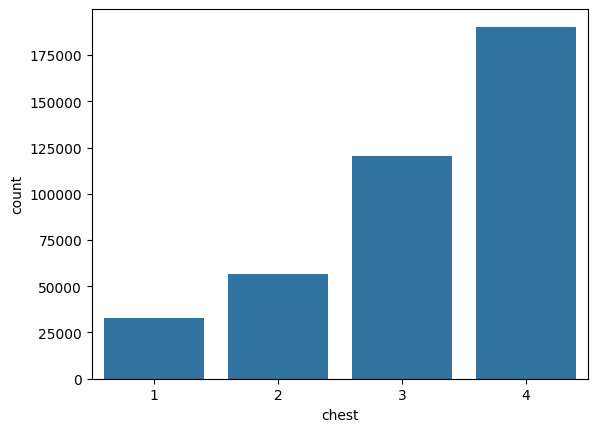

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='chest', data=df_test)

 Из финального набора были удалены признаки ***ID и fasting_blood_sugar***

In [46]:
cols_to_drop = ['ID', 'fasting_blood_sugar']
df_test = df_test.drop(columns=cols_to_drop)

In [47]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400000 entries, 0 to 399999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   age                                   400000 non-null  float64
 1   sex                                   400000 non-null  int64  
 2   chest                                 400000 non-null  int64  
 3   resting_blood_pressure                400000 non-null  float64
 4   serum_cholestoral                     400000 non-null  float64
 5   resting_electrocardiographic_results  400000 non-null  int64  
 6   maximum_heart_rate_achieved           400000 non-null  float64
 7   exercise_induced_angina               400000 non-null  int64  
 8   oldpeak                               400000 non-null  float64
 9   slope                                 400000 non-null  int64  
 10  number_of_major_vessels               400000 non-null  int64  
 11  

In [48]:
summary = pd.DataFrame({
    'dtype': df_test.dtypes,
    'n_unique': df_test.nunique(),
    'min': df_test.min(),
    'max': df_test.max()
})

summary

,dtype,n_unique,min,max
age,float64,397391,27.496874,80.751628
sex,int64,2,0.000000,1.000000
chest,int64,4,1.000000,4.000000
resting_blood_pressure,float64,398274,85.830892,212.300808
serum_cholestoral,float64,399436,94.958220,527.712687
resting_electrocardiographic_results,int64,3,0.000000,2.000000
maximum_heart_rate_achieved,float64,398888,58.964662,207.412021
exercise_induced_angina,int64,2,0.000000,1.000000
oldpeak,float64,262462,-0.601414,6.856219
slope,int64,3,1.000000,3.000000


**Кодирование идентичного набора  категориальных признаков**

In [49]:
# кодирование one-hot
df_test = pd.get_dummies(df_test, columns=cat_cols, drop_first=True)

In [50]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400000 entries, 0 to 399999
Data columns (total 17 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   age                                     400000 non-null  float64
 1   sex                                     400000 non-null  int64  
 2   resting_blood_pressure                  400000 non-null  float64
 3   serum_cholestoral                       400000 non-null  float64
 4   maximum_heart_rate_achieved             400000 non-null  float64
 5   exercise_induced_angina                 400000 non-null  int64  
 6   oldpeak                                 400000 non-null  float64
 7   number_of_major_vessels                 400000 non-null  int64  
 8   chest_2                                 400000 non-null  bool   
 9   chest_3                                 400000 non-null  bool   
 10  chest_4                                 4000

In [51]:
cols = df_test.filter(regex='chest|resting_electrocardiographic_results|slope|thal').columns

df_test[cols] = df_test[cols].astype(int)

In [52]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400000 entries, 0 to 399999
Data columns (total 17 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   age                                     400000 non-null  float64
 1   sex                                     400000 non-null  int64  
 2   resting_blood_pressure                  400000 non-null  float64
 3   serum_cholestoral                       400000 non-null  float64
 4   maximum_heart_rate_achieved             400000 non-null  float64
 5   exercise_induced_angina                 400000 non-null  int64  
 6   oldpeak                                 400000 non-null  float64
 7   number_of_major_vessels                 400000 non-null  int64  
 8   chest_2                                 400000 non-null  int64  
 9   chest_3                                 400000 non-null  int64  
 10  chest_4                                 4000

После one-hot кодирования проведена проверка согласованности признаков в обучающем и тестовом наборах. Наборы содержат идентичные столбцы, что обеспечивает корректную работу моделей.

In [53]:
train_cols = set(df_train.columns) - {'class'}
test_cols = set(df_test.columns)

print(train_cols - test_cols)
print(test_cols - train_cols)

set()
set()


**Обработанные и закодированные наборы данных были сохранены в отдельные файлы.**

In [54]:
#  сохранение файлов

df_train.to_csv('DATA/train_final.csv', index=False)
df_test.to_csv('DATA/test_final.csv', index=False)

## Построение моделей бинарной классификации для диагностики заболеваемости и смертности от сердечно-сосудистых заболеваний

Наша целевая переменная принимает два значения - 1 или 0, что позволяет отнести задачу к бинарной классификации. 

Цель модели — на основании доступных клинических и инструментальных данных, предсказать наличие сердечно-сосудистых заболеваний.


**Разделение данных на тестовый и валидационный сеты**

In [55]:
#  загружаем сохраненный ранее подготовленный и очищенный train set, сформированный на этапе EDA

import pandas as pd

df_trf = pd.read_csv('DATA/train_final.csv')

In [56]:
df_trf.shape
df_trf.info()
df_trf.head().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600000 entries, 0 to 599999
Data columns (total 18 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   age                                     600000 non-null  float64
 1   sex                                     600000 non-null  int64  
 2   resting_blood_pressure                  600000 non-null  float64
 3   serum_cholestoral                       600000 non-null  float64
 4   maximum_heart_rate_achieved             600000 non-null  float64
 5   exercise_induced_angina                 600000 non-null  int64  
 6   oldpeak                                 600000 non-null  float64
 7   number_of_major_vessels                 600000 non-null  int64  
 8   class                                   600000 non-null  int64  
 9   chest_2                                 600000 non-null  int64  
 10  chest_3                                 6000

,0,1,2,3,4
age,49.207124,53.628425,49.591426,58.991445,51.053602
sex,0.000000,1.000000,1.000000,1.000000,1.000000
resting_blood_pressure,162.996167,130.233730,146.999012,112.369143,138.032047
serum_cholestoral,181.108682,276.474630,223.300517,187.245501,238.482868
maximum_heart_rate_achieved,148.227858,152.917139,102.352090,158.164750,172.540828
exercise_induced_angina,1.000000,0.000000,1.000000,1.000000,0.000000
oldpeak,0.944547,0.119070,1.616747,0.000000,1.150464
number_of_major_vessels,0.000000,0.000000,2.000000,1.000000,1.000000
class,1.000000,0.000000,1.000000,1.000000,0.000000
chest_2,0.000000,1.000000,0.000000,0.000000,1.000000


Прежде чем приступить к построению модели, данные разделили на два массива - переменная **Х** - массив признаков, переменная **y** - целевая переменная(target - class).

In [57]:
X = df_trf.drop('class', axis=1)
y = df_trf['class']

print(X.head(3).T)
print(y.head(3).T)

                                                 0           1           2
age                                      49.207124   53.628425   49.591426
sex                                       0.000000    1.000000    1.000000
resting_blood_pressure                  162.996167  130.233730  146.999012
serum_cholestoral                       181.108682  276.474630  223.300517
maximum_heart_rate_achieved             148.227858  152.917139  102.352090
exercise_induced_angina                   1.000000    0.000000    1.000000
oldpeak                                   0.944547    0.119070    1.616747
number_of_major_vessels                   0.000000    0.000000    2.000000
chest_2                                   0.000000    1.000000    0.000000
chest_3                                   0.000000    0.000000    0.000000
chest_4                                   1.000000    0.000000    1.000000
resting_electrocardiographic_results_1    0.000000    0.000000    0.000000
resting_electrocardiograp

In [58]:
print(X.shape, y.shape)
print(y.value_counts(normalize=True))

(600000, 17) (600000,)
class
0    0.555815
1    0.444185
Name: proportion, dtype: float64


In [59]:
list(X.columns)

['age',
 'sex',
 'resting_blood_pressure',
 'serum_cholestoral',
 'maximum_heart_rate_achieved',
 'exercise_induced_angina',
 'oldpeak',
 'number_of_major_vessels',
 'chest_2',
 'chest_3',
 'chest_4',
 'resting_electrocardiographic_results_1',
 'resting_electrocardiographic_results_2',
 'slope_2',
 'slope_3',
 'thal_6',
 'thal_7']

In [106]:
# сохраняем список признаков для инференса

import joblib

joblib.dump(X.columns.tolist(), "MODEL/columns.pkl")

['MODEL/columns.pkl']

Исходные данные уже разделены на обучающую и тестовую выборки.
Для подбора гиперпараметров обучающая выборка дополнительно разделена на обучающую и валидационную (80/20).
Использовано стратифицированное разбиение для сохранения баланса классов.

In [61]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [62]:
y_train.value_counts(normalize=True)


class
0    0.555815
1    0.444185
Name: proportion, dtype: float64

После стратифицированного разбиения выборки доля классов в обучающей и тестовой подвыборках сохраняется

In [63]:
baseline = y.mean()
print("Baseline accuracy:", max(baseline, 1-baseline))

Baseline accuracy: 0.555815


Доля положительного класса составляет 0.555. Соответственно, наивная модель, всегда предсказывающая наиболее частый класс, уже достигает accuracy 55.5%. Данный показатель используется как baseline для дальнейшего сравнения моделей.

**Логистическая регрессия (LogisticRegression)**

В качестве первой модели была выбрана логистическая регрессия (LogisticRegression)
Логистическая регрессия позволяет определить базовый уровень качества классификации и оценить наличие линейной структуры в данных. 

В задаче диагностики приоритетом является минимизация пропуска положительного класса, поэтому в качестве основной метрики выбрана recall. Дополнительно оценивается F1-score как баланс между полнотой и точностью.

Обучим модель

In [64]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score)

#  масштабирование данных
scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_val_scaled   = scaler.transform(X_val)

#  модель
model = LogisticRegression(max_iter=1000, random_state=42)

#  обучение модели
model.fit(X_train_scaled, y_train)

# предсказание

y_pred = model.predict(X_val_scaled)
y_proba = model.predict_proba(X_val_scaled)[:, 1]

roc_auc = roc_auc_score(y_val, y_proba)

print("Recall:", recall_score(y_val, y_pred))
print("F1:", f1_score(y_val, y_pred))
print("Accuracy:", accuracy_score(y_val, y_pred))
print("ROC-AUC:", roc_auc)
print("Presicion:", precision_score(y_val, y_pred))

Recall: 0.8613372856553225
F1: 0.8710442437580633
Accuracy: 0.8867166666666667
ROC-AUC: 0.954267907726384
Presicion: 0.880972483401773


В рамках задачи бинарной классификации (предсказание наличия диагноза) были использованы следующие метрики: accuracy, recall, F1-score и ROC-AUC.

Recall (0.8613)
Доля правильно найденных положительных случаев среди всех реальных положительных.
Модель выявляет около 86% пациентов с диагнозом.
Для медицинской задачи это важная метрика, поскольку отражает способность не пропускать больных.

F1-score (0.871)
Гармоническое среднее precision и recall.
Позволяет оценить баланс между чувствительностью и точностью.
Значение 0.871 указывает на относительно сбалансированную работу модели.

Accuracy (0.886)
Доля правильно классифицированных пациентов.
В данном случае модель правильно классифицирует около 88.7% наблюдений. Однако при наличии дисбаланса классов accuracy не является ключевой метрикой.

ROC-AUC (0.954)
Оценивает способность модели ранжировать пациентов по вероятности наличия диагноза.
Значение 0.954 означает, что в 95% случайно выбранных пар (пациент с диагнозом и без) модель присваивает более высокую вероятность положительного класса пациенту с диагнозом.

Precision (0.880)
То есть из пациентов, которым модель «поставила» диагноз, около 88% действительно имеют его.

В логистической регрессии модель возвращает вероятность принадлежности к положительному классу.
Для получения бинарного прогноза используется пороговое значение (threshold), при котором вероятность выше заданного уровня интерпретируется как «наличие заболевания».

По умолчанию в scikit-learn используется значение 0.5.
На первом этапе анализа применяется стандартный порог 0.5 без его изменения.

В данной задаче приоритет отдан метрике recall, поскольку пропуск заболевания является более критичной ошибкой, чем ложноположительное предсказание.


In [65]:
# Созраняем метрики для дальнейшего сравнения.

# метрики LogisticRegression Threshold=0.50 (default)

recall_LR_05=0.861
precision_LR_05=0.880
roc_auc_LR_05=0.954

Для последующего сравнения моделей в качестве основных показателей выбраны recall, precision и ROC-AUC.

**Визуализируем ROC-кривые**

Для анализа способности модели различать классы построена ROC-кривая на тестовой выборке. Кривая отражает зависимость чувствительности (True Positive Rate) от доли ложноположительных решений (False Positive Rate) при изменении порога классификации. Площадь под кривой (ROC-AUC) используется как интегральная оценка качества ранжирования.

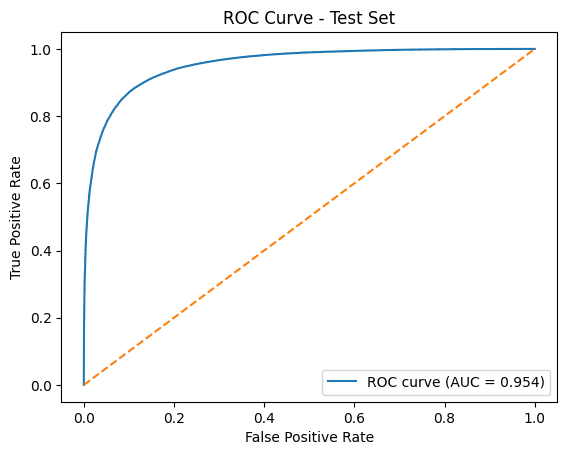

In [66]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_val, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Test Set")
plt.legend()
plt.show()

Несмотря на простоту модели, полученные данные показывают, что модель имеет хорошую разделяющую способность, что свидетельствует о наличии сильного сигнала в данных.

Дополнительно рассмотрена матрица ошибок при стандартном пороге 0.5. Это позволяет оценить фактическое распределение ложноположительных и ложноотрицательных решений.

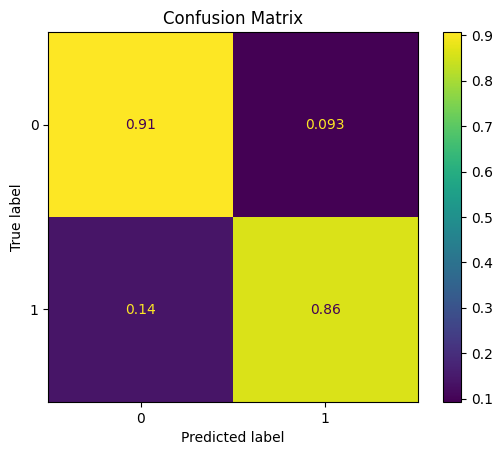

In [67]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_val, y_pred, normalize='true'
)

plt.title("Confusion Matrix")
plt.show()

Несмотря на высокую общую точность модели, анализ матрицы ошибок показывает, что часть положительных случаев остаются нераспознанными. 
Значение ошибок составляет около 14% пропусков положительного класса.
С учётом медицинской специфики задачи это может быть критичным, поэтому далее имеет смысл рассмотреть изменение порогового значения для увеличения полноты (recall).

**Попробуем улучшить модель**

Порог классификации был скорректирован с целью повышения чувствительности модели.

In [68]:
import numpy as np
from sklearn.metrics import recall_score, precision_score

thresholds = np.linspace(0.1, 0.9, 50)

for t in thresholds:
    y_temp = (y_proba >= t).astype(int)
    rec = recall_score(y_val, y_temp)
    prec = precision_score(y_val, y_temp)
    print(f"Threshold={t:.2f}  Recall={rec:.3f}  Precision={prec:.3f}")

Threshold=0.10  Recall=0.976  Precision=0.687
Threshold=0.12  Recall=0.972  Precision=0.704
Threshold=0.13  Recall=0.967  Precision=0.718
Threshold=0.15  Recall=0.963  Precision=0.732
Threshold=0.17  Recall=0.959  Precision=0.743
Threshold=0.18  Recall=0.955  Precision=0.754
Threshold=0.20  Recall=0.950  Precision=0.765
Threshold=0.21  Recall=0.946  Precision=0.774
Threshold=0.23  Recall=0.942  Precision=0.783
Threshold=0.25  Recall=0.937  Precision=0.791
Threshold=0.26  Recall=0.932  Precision=0.799
Threshold=0.28  Recall=0.928  Precision=0.806
Threshold=0.30  Recall=0.923  Precision=0.813
Threshold=0.31  Recall=0.919  Precision=0.820
Threshold=0.33  Recall=0.915  Precision=0.826
Threshold=0.34  Recall=0.910  Precision=0.833
Threshold=0.36  Recall=0.905  Precision=0.838
Threshold=0.38  Recall=0.900  Precision=0.844
Threshold=0.39  Recall=0.895  Precision=0.850
Threshold=0.41  Recall=0.891  Precision=0.855
Threshold=0.43  Recall=0.886  Precision=0.860
Threshold=0.44  Recall=0.881  Prec

**Визуализация зависимости Precision/Recall от Threshold**

Для логистической регрессии отсутствует итеративный процесс обучения по эпохам, поэтому графики обучения не применимы. Вместо этого анализируется поведение модели при изменении порога классификации. На графике показана зависимость precision и recall от значения threshold, что позволяет выбрать оптимальный баланс между метриками.

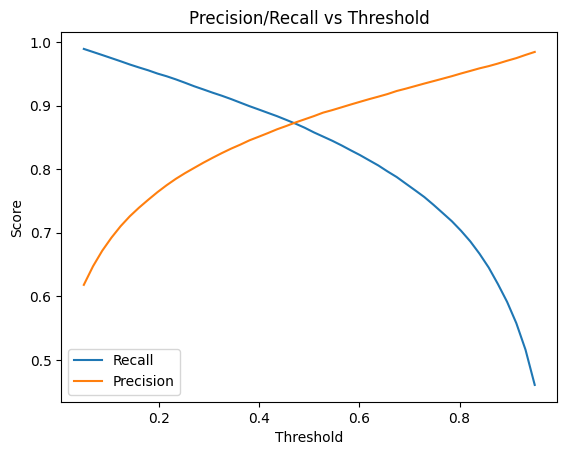

In [69]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score

thresholds = np.linspace(0.05, 0.95, 50)

precisions = []
recalls = []

for t in thresholds:
    y_temp = (y_proba >= t).astype(int)
    precisions.append(precision_score(y_val, y_temp))
    recalls.append(recall_score(y_val, y_temp))

plt.figure()
plt.plot(thresholds, recalls, label="Recall")
plt.plot(thresholds, precisions, label="Precision")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision/Recall vs Threshold")
plt.legend()
plt.show()

Анализ зависимости precision и recall от порогового значения показал, что в диапазоне 0.42–0.46 достигается баланс между метриками. Снижение порога до значений около 0.35–0.4 позволяет дополнительно увеличить recall при умеренном снижении precision, что может быть предпочтительно с учётом приоритета минимизации пропусков положительного класса.

В результате анализа зависимости precision и recall от порогового значения было выбрано значение threshold = 0.33, позволяющее увеличить recall до 0.92 при приемлемом уровне precision (0.83). Данный выбор соответствует приоритету минимизации пропуска положительного класса

При этом увеличение recall достигается за счёт роста числа ложноположительных предсказаний, что является ожидаемым компромиссом.

In [70]:
# Созраняем метрики для дальнейшего сравнения.

# метрики LogisticRegression Threshold=0.50 (default)

recall_LR_05=0.861
precision_LR_05=0.880
roc_auc_LR_05=0.954

# метрики LogisticRegression Threshold=0.33 (tuned)

recall_LR_033=0.915
precision_LR_033=0.826
roc_auc_LR_033=0.954

**Вклад признаков в формирование прогноза**

In [71]:
coefs = pd.Series(
    model.coef_[0],
    index=X_train.columns
).sort_values(ascending=False)

print(coefs.head(10))

thal_7                                    1.060237
number_of_major_vessels                   1.032656
chest_4                                   0.924086
oldpeak                                   0.738861
exercise_induced_angina                   0.612317
slope_2                                   0.541718
resting_electrocardiographic_results_2    0.367445
sex                                       0.339501
thal_6                                    0.293502
age                                       0.286249
dtype: float64


**Наибольшее влияние на прогноз** оказывают следующие признаки (топ-5 по величине коэффициентов):

thal_7                                   

number_of_major_vessels

chest_4                               

oldpeak

exercise_induced_angina       

## Применение ансамблевого классификатора - RandomForestClassifier

В качестве следующей модели был выбран ансамблевый метод ***RandomForestClassifier***. Данная модель позволяет учитывать нелинейные зависимости и взаимодействия между признаками. Random Forest обладает относительной устойчивостью к переобучению за счёт усреднения предсказаний множества деревьев. Использование данной модели направлено на проверку, приводит ли увеличение сложности алгоритма к улучшению качества классификации по сравнению с базовой моделью - ***LogisticRegression***.

In [72]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

# обучение
rf.fit(X_train, y_train)

# предсказания
y_pred = rf.predict(X_val)
y_proba = rf.predict_proba(X_val)[:, 1]

# метрики
print("Validation metrics:")
print(f"Accuracy:  {accuracy_score(y_val, y_pred):.3f}")
print(f"F1:        {f1_score(y_val, y_pred):.3f}")
print(f"Precision: {precision_score(y_val, y_pred):.3f}")
print(f"Recall:    {recall_score(y_val, y_pred):.3f}")
print(f"ROC-AUC:   {roc_auc_score(y_val, y_proba):.3f}")

Validation metrics:
Accuracy:  0.898
F1:        0.884
Precision: 0.892
Recall:    0.876
ROC-AUC:   0.961


In [73]:
# Созраняем метрики для дальнейшего сравнения.

# метрики LogisticRegression Threshold=0.50 (default)

recall_LR_05=0.861
precision_LR_05=0.880
roc_auc_LR_05=0.954

# метрики LogisticRegression Threshold=0.33 (tuned)

recall_LR_033=0.915
precision_LR_033=0.826
roc_auc_LR_033=0.954

# метрики RandomForestClassifier default

recall_RFC_D=0.876
precision_RFC_D=0.892
roc_auc_RFC_D=0.961


**Подбор гиперпараметров**

Для оптимизации ***RandomForestClassifier*** были выбраны гиперпараметры, влияющие на сложность модели и её обобщающую способность.

Параметры n_estimators и max_depth определяют мощность ансамбля и глубину отдельных деревьев, а min_samples_split и min_samples_leaf регулируют степень детализации разбиений и позволяют ограничивать переобучение.

Параметр max_features контролирует количество признаков, используемых при построении каждого разбиения, что влияет на вариативность деревьев и устойчивость ансамбля.

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [ 10, 20],
    "min_samples_split": [2, 10],
    "min_samples_leaf": [1, 4],
    "max_features": [3, 5, 7]
}

results = []

for params in ParameterGrid(param_grid):
    rf = RandomForestClassifier(
        **params,
        random_state=42,
        n_jobs=-1
    )
    
    rf.fit(X_train, y_train)
    
    y_pred = rf.predict(X_val)
    y_proba = rf.predict_proba(X_val)[:, 1]
    
    results.append({
        **params,
        "f1": f1_score(y_val, y_pred),
        "precision": precision_score(y_val, y_pred),
        "recall": recall_score(y_val, y_pred),
        "roc_auc": roc_auc_score(y_val, y_proba)
    })

df_results = pd.DataFrame(results)

# сохранение
df_results.to_csv("DATA/RFC_grid_results.csv", index=False)

print("GridSearch results saved to 'RFC_grid_results.csv'")

Полученные гиперпараметры были сохранены в таблицу.

**Выбор лучших гиперпараметров**

Отбор лучших гиперпараметров проводился по f1 (фактор компромисcа между recall  и precision)

In [76]:
import pandas as pd

grid_results = pd.read_csv("DATA/RFC_grid_results.csv")

# сортируем по mean_test_score (если scoring='roc_auc')

best_row = grid_results.sort_values(by="f1", ascending=False).iloc[0]

print("Best paremeters:", round(best_row["f1"], 4))

best_params = {
    "n_estimators": int(best_row["n_estimators"]),
    "max_depth": int(best_row["max_depth"]),
    "min_samples_split": int(best_row["min_samples_split"]),
    "min_samples_leaf": int(best_row["min_samples_leaf"]),
    "max_features": int(best_row["max_features"]),
}

print("Best parameters:", best_params)

Best paremeters: 0.8863
Best parameters: {'n_estimators': 200, 'max_depth': 20, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 3}


Отсортируем строки с лучшими гиперпараметрами (по f1)

In [ ]:
grid_results = grid_results.sort_values(by="f1", ascending=False)
grid_results.head(6).T

В ходе подбора гиперпараметров для модели RandomForestClassifier был проведён перебор параметров на валидационной выборке. Анализ результатов показал, что несколько комбинаций дают практически одинаковое значение метрики F1, что указывает на наличие устойчивой области оптимальных параметров, а не единичного максимума.

В качестве итоговой конфигурации выбрана комбинация параметров:

n_estimators = 200

max_depth = 20

min_samples_split = 2

min_samples_leaf = 4

max_features = 3

Данный набор параметров обеспечивает высокий уровень качества модели при сохранении её разумной вычислительной сложности. Выбор сделан на основе анализа группы лучших результатов, а не одной максимальной точки.

In [78]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

rf_final = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=4,
    max_features=3,
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X_train, y_train)

# предсказания
y_pred = rf_final.predict(X_val)
y_proba = rf_final.predict_proba(X_val)[:, 1]

# метрики
print("Validation metrics (RFC_T):")
print(f"Accuracy:  {accuracy_score(y_val, y_pred):.3f}")
print(f"F1:        {f1_score(y_val, y_pred):.3f}")
print(f"Precision: {precision_score(y_val, y_pred):.3f}")
print(f"Recall:    {recall_score(y_val, y_pred):.3f}")
print(f"ROC-AUC:   {roc_auc_score(y_val, y_proba):.3f}")

Validation metrics (RFC_T):
Accuracy:  0.900
F1:        0.886
Precision: 0.895
Recall:    0.878
ROC-AUC:   0.962


In [79]:
# Созраняем метрики для дальнейшего сравнения.

# метрики LogisticRegression Threshold=0.50 (default)

recall_LR_05=0.861
precision_LR_05=0.880
roc_auc_LR_05=0.954

# метрики LogisticRegression Threshold=0.33 (tuned)

recall_LR_033=0.915
precision_LR_033=0.826
roc_auc_LR_033=0.954

# метрики RandomForestClassifier default

recall_RFC_D=0.876
precision_RFC_D=0.892
roc_auc_RFC_D=0.961

# метрики RandomForestClassifier tuned
recall_RFC_T=0.878
precision_RFC_T=0.895
roc_auc_RFC_T=0.962

**Анализ влияния порога классификации на метрики модели**. Снижение значения threshold приводит к увеличению recall за счёт снижения precision.

In [80]:
import numpy as np
from sklearn.metrics import precision_score, recall_score

thresholds = np.linspace(0.1, 0.9, 20)

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    
    precision = precision_score(y_val, y_pred_t)
    recall = recall_score(y_val, y_pred_t)
    
    print(f"threshold={t:.2f} | precision={precision:.3f} | recall={recall:.3f}")

threshold=0.10 | precision=0.683 | recall=0.982
threshold=0.14 | precision=0.724 | recall=0.973
threshold=0.18 | precision=0.757 | recall=0.965
threshold=0.23 | precision=0.784 | recall=0.956
threshold=0.27 | precision=0.806 | recall=0.946
threshold=0.31 | precision=0.826 | recall=0.935
threshold=0.35 | precision=0.843 | recall=0.924
threshold=0.39 | precision=0.861 | recall=0.912
threshold=0.44 | precision=0.875 | recall=0.899
threshold=0.48 | precision=0.889 | recall=0.886
threshold=0.52 | precision=0.900 | recall=0.869
threshold=0.56 | precision=0.911 | recall=0.852
threshold=0.61 | precision=0.922 | recall=0.834
threshold=0.65 | precision=0.932 | recall=0.812
threshold=0.69 | precision=0.941 | recall=0.789
threshold=0.73 | precision=0.950 | recall=0.762
threshold=0.77 | precision=0.958 | recall=0.730
threshold=0.82 | precision=0.966 | recall=0.690
threshold=0.86 | precision=0.974 | recall=0.638
threshold=0.90 | precision=0.982 | recall=0.569


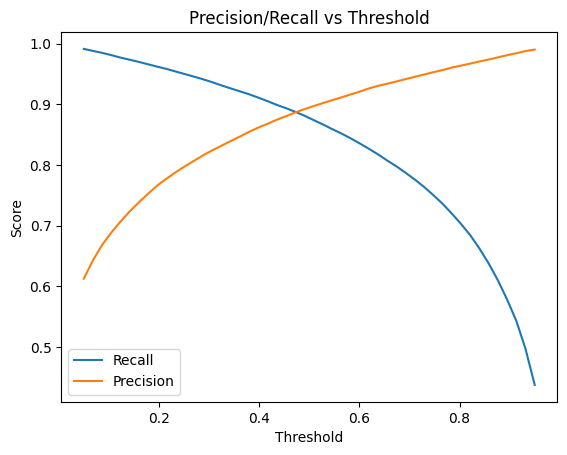

In [81]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score

thresholds = np.linspace(0.05, 0.95, 50)

precisions = []
recalls = []

for t in thresholds:
    y_temp = (y_proba >= t).astype(int)
    precisions.append(precision_score(y_val, y_temp))
    recalls.append(recall_score(y_val, y_temp))

plt.figure()
plt.plot(thresholds, recalls, label="Recall")
plt.plot(thresholds, precisions, label="Precision")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision/Recall vs Threshold")
plt.legend()
plt.show()

Для RandomForestClassifier был дополнительно проанализирован эффект изменения порога классификации. Установлено, что при threshold ≈ 0.39 достигается более высокий recall (0.912) при умеренном снижении precision (0.861), что позволяет сместить модель в сторону более агрессивного выявления положительного класса.

**ROC-кривая** для ***RandomForestClassifier***

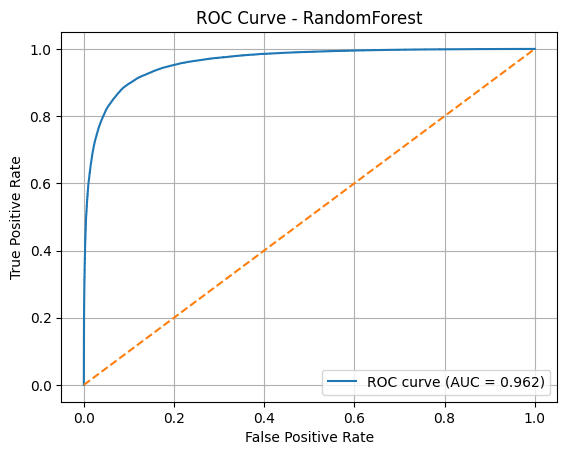

In [82]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# вероятности
y_proba = rf_final.predict_proba(X_val)[:, 1]

# ROC
fpr, tpr, thresholds = roc_curve(y_val, y_proba)
roc_auc = roc_auc_score(y_val, y_proba)

plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - RandomForest')
plt.legend()
plt.grid()

plt.show()

Сравнение матриц ошибок модели ***RandomForestClassifier*** (default & tuned) при разных настройках порога классификации

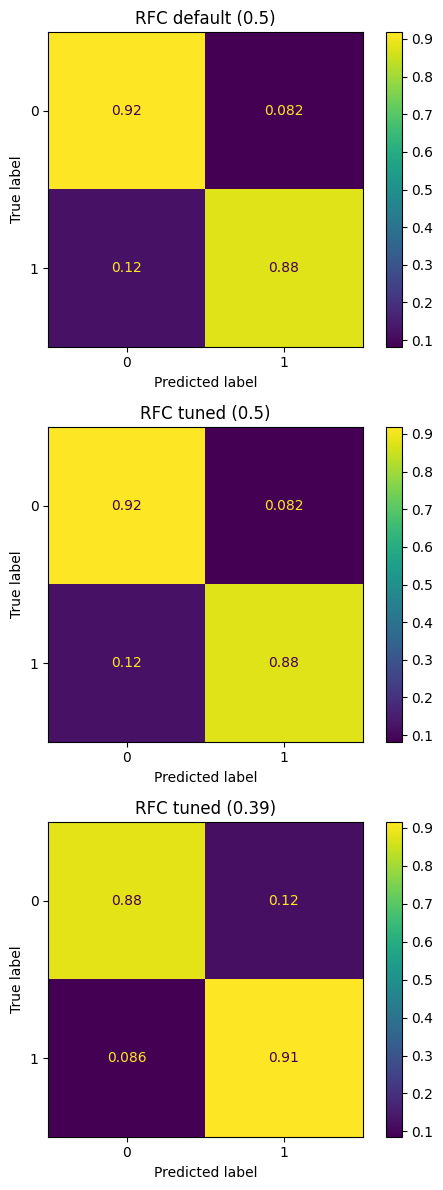

In [95]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# предсказания 
y_pred_default = rf_final.predict(X_val)
y_pred_tuned = rf_final.predict(X_val)

y_proba = rf_final.predict_proba(X_val)[:, 1]
y_pred_039 = (y_proba >= 0.39).astype(int)

# фигура 
fig, axes = plt.subplots(3, 1, figsize=(5, 12))

# 1. Default
ConfusionMatrixDisplay.from_predictions(
    y_val, y_pred_default,
    normalize='true',
    ax=axes[0]
)
axes[0].set_title("RFC default (0.5)")

# 2. Tuned (0.5)
ConfusionMatrixDisplay.from_predictions(
    y_val, y_pred_tuned,
    normalize='true',
    ax=axes[1]
)
axes[1].set_title("RFC tuned (0.5)")

# 3. Tuned (0.39)
ConfusionMatrixDisplay.from_predictions(
    y_val, y_pred_039,
    normalize='true',
    ax=axes[2]
)
axes[2].set_title("RFC tuned (0.39)")

plt.tight_layout()
plt.show()

In [ ]:
# Созраняем метрики для дальнейшего сравнения.

# метрики LogisticRegression Threshold=0.50 (default)

recall_LR_05=0.861
precision_LR_05=0.880
roc_auc_LR_05=0.954

# метрики LogisticRegression Threshold=0.33 (tuned)

recall_LR_033=0.915
precision_LR_033=0.826
roc_auc_LR_033=0.954

# метрики RandomForestClassifier default

recall_RFC_D=0.876
precision_RFC_D=0.892
roc_auc_RFC_D=0.961

# метрики RandomForestClassifier tuned
recall_RFC_T=0.878
precision_RFC_T=0.895
roc_auc_RFC_T=0.962

# метрики RandomForestClassifier tuned, threshold 0.39
recall_RFC_T_039=0.912
precision_RFC_T_039=0.861
roc_auc_RFC_T_039=0.962


**Оценка значимости признаков в RandomForestClassifier**

Для анализа структуры ансамблевой модели была рассмотрена встроенная оценка важности признаков (feature importance).

Ниже приведены признаки с наибольшей значимостью.

In [87]:
import pandas as pd

feature_importance = pd.Series(
    rf_final.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

feature_importance.head(10)

thal_7                         0.169430
number_of_major_vessels        0.144543
chest_4                        0.136920
maximum_heart_rate_achieved    0.100567
oldpeak                        0.098361
exercise_induced_angina        0.082103
age                            0.063129
slope_2                        0.050289
serum_cholestoral              0.032613
sex                            0.031776
dtype: float64

Анализ важности признаков показал наличие устойчивого набора наиболее информативных переменных, совпадающих для разных моделей (например, thal, number_of_major_vessels, chest pain type, oldpeak). При этом RandomForest выявляет дополнительную значимость признаков, связанных с более сложными зависимостями (например, максимальная частота сердечных сокращений).

## Neural Network

В дополнение к классическим моделям была обучена полносвязная нейронная сеть. Данная модель позволяет учитывать сложные нелинейные зависимости между признаками, однако на табличных данных её преимущества проявляются не всегда.

In [88]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler

# Стандартиззация данных

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Tourch tensors 

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_t = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)

# Модель

class SimpleNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

input_dim = X_train_t.shape[1]
model = SimpleNN(input_dim)

# LOSS + OPTIMIZER

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Обучение модели

num_epochs = 150
train_losses = []
val_losses = []

for epoch in range(num_epochs):

    # train 
    model.train()
    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    #  val
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val_t)
        val_loss = criterion(val_outputs, y_val_t)
        val_losses.append(val_loss.item())

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Train: {loss.item():.4f}, Val: {val_loss.item():.4f}")

# сохранение модели

torch.save(model.state_dict(), "simple_nn.pth")

Epoch 0, Train: 0.7100, Val: 0.7056
Epoch 10, Train: 0.6702, Val: 0.6664
Epoch 20, Train: 0.6313, Val: 0.6274
Epoch 30, Train: 0.5864, Val: 0.5817
Epoch 40, Train: 0.5318, Val: 0.5262
Epoch 50, Train: 0.4704, Val: 0.4648
Epoch 60, Train: 0.4106, Val: 0.4058
Epoch 70, Train: 0.3610, Val: 0.3577
Epoch 80, Train: 0.3259, Val: 0.3240
Epoch 90, Train: 0.3038, Val: 0.3030
Epoch 100, Train: 0.2907, Val: 0.2905
Epoch 110, Train: 0.2832, Val: 0.2833
Epoch 120, Train: 0.2788, Val: 0.2790
Epoch 130, Train: 0.2761, Val: 0.2764
Epoch 140, Train: 0.2743, Val: 0.2746


**Кривые обучения модели (learning curves)**

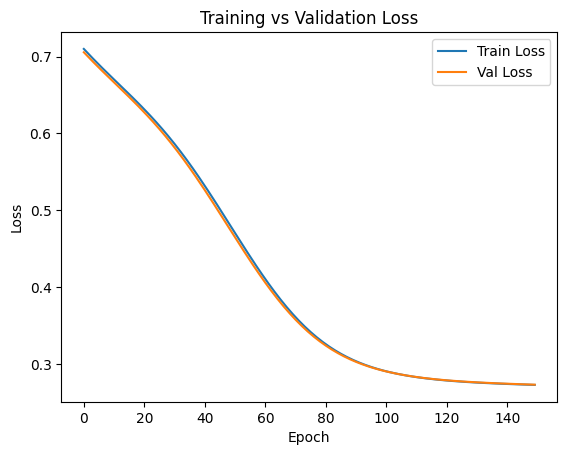

In [89]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

На графике представлены кривые обучения модели на обучающей и валидационной выборках. 

В начале обучения наблюдается быстрое снижение функции потерь, что свидетельствует об эффективном обучении модели. 

После ~80–100 эпох скорость снижения замедляется, что указывает на достижение плато. 

Кривые практически совпадают, что говорит об отсутствии переобучения и хорошей обобщающей способности модели.

Метрики модели

In [90]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# вероятности
model.eval()
with torch.no_grad():
    val_proba = model(X_val_t).numpy()

# порог (можешь взять свой любимый 0.39)
threshold = 0.5
val_pred = (val_proba > threshold).astype(int)

y_true = y_val.values

# метрики
acc = accuracy_score(y_true, val_pred)
prec = precision_score(y_true, val_pred)
rec = recall_score(y_true, val_pred)
f1 = f1_score(y_true, val_pred)
roc = roc_auc_score(y_true, val_proba)

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1: {f1:.4f}")
print(f"ROC-AUC: {roc:.4f}")

Accuracy: 0.8867
Precision: 0.8817
Recall: 0.8603
F1: 0.8709
ROC-AUC: 0.9538


C:\Users\rezma\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


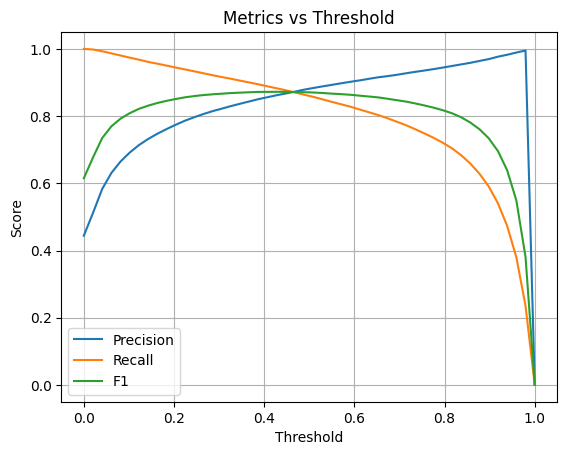

In [91]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.linspace(0, 1, 50)

precision_list = []
recall_list = []
f1_list = []

for t in thresholds:
    preds = (val_proba > t).astype(int)
    
    precision_list.append(precision_score(y_true, preds))
    recall_list.append(recall_score(y_true, preds))
    f1_list.append(f1_score(y_true, preds))

# график
plt.plot(thresholds, precision_list, label="Precision")
plt.plot(thresholds, recall_list, label="Recall")
plt.plot(thresholds, f1_list, label="F1")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Metrics vs Threshold")
plt.legend()
plt.grid()

plt.show()

При высоких значениях порога модель перестаёт предсказывать положительный класс, что приводит к неопределённости метрики precision (деление 0/0).

Точка пересечения precision и recall наблюдается при threshold около 0.48, что соответствует равенству метрик. Однако максимальное значение F1 достигается при несколько бОльшем значении порога (~0.5), что указывает на более оптимальный баланс между precision и recall.

In [92]:
import pandas as pd
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.linspace(0, 1, 40)

df_metrics = pd.DataFrame({
    "threshold": thresholds
})

df_metrics["precision"] = df_metrics["threshold"].apply(
    lambda t: precision_score(y_true, (val_proba > t).astype(int), zero_division=0)
)

df_metrics["recall"] = df_metrics["threshold"].apply(
    lambda t: recall_score(y_true, (val_proba > t).astype(int))
)

df_metrics["f1"] = df_metrics["threshold"].apply(
    lambda t: f1_score(y_true, (val_proba > t).astype(int))
)

df_metrics.head(30)

,threshold,precision,recall,f1
0,0.000000,0.444183,1.000000,0.615134
1,0.025641,0.532958,0.997205,0.694656
2,0.051282,0.609473,0.989494,0.754325
3,0.076923,0.657945,0.981783,0.787886
4,0.102564,0.692354,0.973753,0.809290
5,0.128205,0.719401,0.966080,0.824689
6,0.153846,0.740617,0.958125,0.835446
7,0.179487,0.758370,0.951484,0.844022
8,0.205128,0.775196,0.944336,0.851447
9,0.230769,0.790082,0.937094,0.857332


Судя по данным таблицы, максимальное значение F1 достигается при threshold около 0.41. Однако близкие значения порога (0.39–0.45) демонстрируют сопоставимое качество модели.

## Сравнение моделей

In [ ]:
# Созраняем метрики для дальнейшего сравнения.

# метрики LogisticRegression Threshold=0.50 (default)

recall_LR_05=0.861
precision_LR_05=0.880
roc_auc_LR_05=0.954

# метрики LogisticRegression Threshold=0.33 (tuned)

recall_LR_033=0.915
precision_LR_033=0.826
roc_auc_LR_033=0.954

# метрики RandomForestClassifier default

recall_RFC_D=0.876
precision_RFC_D=0.892
roc_auc_RFC_D=0.961

# метрики RandomForestClassifier tuned
recall_RFC_T=0.878
precision_RFC_T=0.895
roc_auc_RFC_T=0.962

# метрики RandomForestClassifier tuned, threshold 0.39

recall_RFC_T_039=0.912
precision_RFC_T_039=0.861
roc_auc_RFC_T_039=0.962

# Neural Network, thershold 0.5

recall_NW_05=0.863
precision_NW_05=0.880
roc_auc_NW_05=0.955

# Neural Network, thershold 0.41

recall_NW_041=0.892
precision_NW_041=0.856
roc_auc_NW_041=0.955

**Визуальное сравнение моделей**

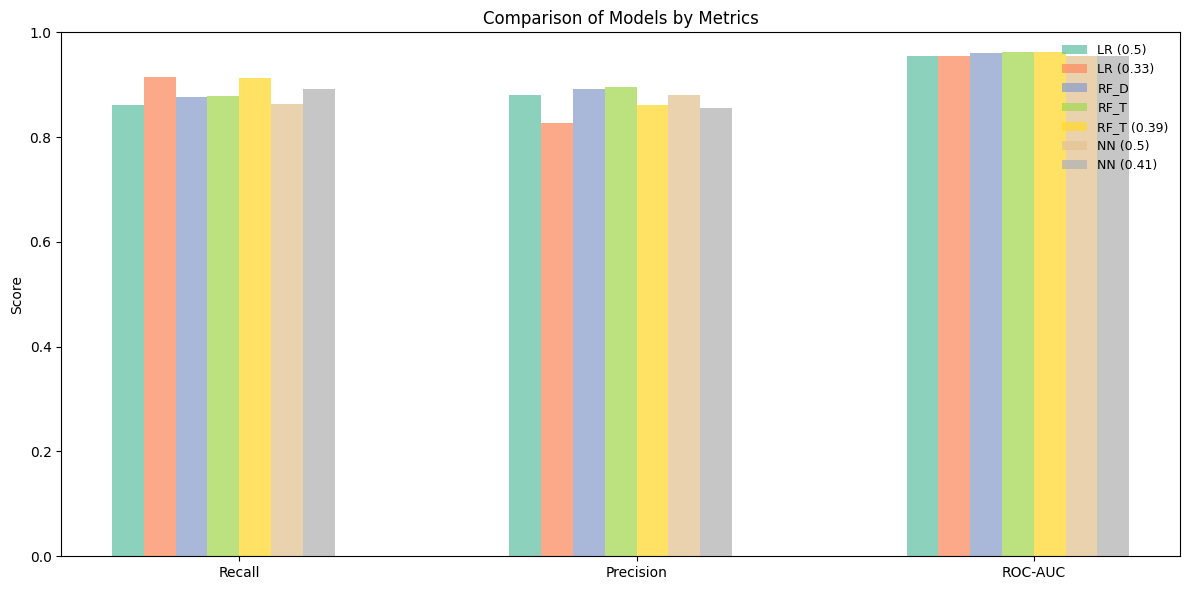

In [93]:
import matplotlib.pyplot as plt
import numpy as np

models = [
    "LR (0.5)", "LR (0.33)",
    "RF_D", "RF_T", "RF_T (0.39)",
    "NN (0.5)", "NN (0.41)"
]

recall = [
    0.861, 0.915,
    0.876, 0.878, 0.912,
    0.863, 0.892
]

precision = [
    0.880, 0.826,
    0.892, 0.895, 0.861,
    0.880, 0.856
]

roc_auc = [
    0.954, 0.954,
    0.961, 0.962, 0.962,
    0.955, 0.955
]

x = np.arange(3)
width = 0.08

colors = plt.cm.Set2(np.linspace(0, 1, len(models)))

fig, ax = plt.subplots(figsize=(12, 6))

for i, model in enumerate(models):
    ax.bar(
        x + i * width,
        [recall[i], precision[i], roc_auc[i]],
        width,
        label=model,
        color=colors[i],
        alpha=0.75
    )

ax.set_xticks(x + width * (len(models) / 2))
ax.set_xticklabels(["Recall", "Precision", "ROC-AUC"])
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Comparison of Models by Metrics")
ax.legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

Логистическая регрессия с пониженным порогом показывает максимальное значение recall, однако ***RandomForestClassifier*** с оптимизированными параметрами и настроенным threshold демонстрирует сопоставимый recall при более высоком precision и ROC-AUC, что делает его более сбалансированным решением.

Нейронная сеть не продемонстрировала улучшения качества по сравнению с другими моделями. Несмотря на сопоставимые значения метрик, она уступает ***RandomForestClassifier*** как по recall, так и по precision и ROC-AUC.

**Сравнение вклада признаков в моделях**

In [94]:
# собираем признаки, вошедшие в топ-5 хотя бы в одной их моделей

top_n = 5

rank_lr = coefs.rank(ascending=False)
rank_rfc = feature_importance.rank(ascending=False)

rank_table = pd.DataFrame({
    "LR": rank_lr,
    "RF": rank_rfc,
})

# оставляем только признаки, которые попали в топ-5 хотя бы одной модели
mask = (
    (rank_table["LR"] <= top_n) |
    (rank_table["RF"] <= top_n) 
   
)

clean_table = rank_table[mask].sort_values(["LR", "RF"])
clean_table = clean_table.astype(int)

clean_table

,LR,RF
thal_7,1,1
number_of_major_vessels,2,2
chest_4,3,3
oldpeak,4,5
exercise_induced_angina,5,6
maximum_heart_rate_achieved,17,4


Сравнение важности признаков для логистической регрессии и **RandomForestClassifier** показало, что модели выделяют похожий набор признаков. ***thal, number_of_major_vessels и chest_4*** занимают ведущие позиции в обеих моделях. Это указывает на то, что влияние этих признаков устойчиво и не зависит от выбранного алгоритма.

Ряд признаков, таких как ***oldpeak и exercise_induced_angina***, также демонстрируют высокую важность, хотя их позиции не полностью совпадают.

Наибольшее расхождение наблюдается для признака maximum_heart_rate_achieved: он не входит в число значимых признаков в логистической регрессии, но занимает высокую позицию в **RandomForestClassifier**. Это может свидетельствовать о наличии нелинейной зависимости между данным признаком и целевой переменной, которую линейная модель не способна уловить.

Для нейронной сети прямая оценка важности признаков не проводилась, так как, в отличие от логистической регрессии и RandomForest, для нейронной сети нельзя напрямую определить важность признаков. Однако сопоставимые значения метрик качества позволяют предположить, что нейронная сеть опирается на те же ключевые признаки, что и другие модели.

## Интерпретация результатов и выбор лучшей модели

***Все рассмотренные модели*** демонстрируют высокую разделяющую способность (ROC-AUC находится в диапазоне ~0.95–0.96), что свидетельствует о хорошем качестве исходных данных и наличии выраженной зависимости между признаками и целевой переменной. 

***Логистическая регрессия*** показывает стабильные результаты и обеспечивает сбалансированное соотношение precision и recall при стандартном пороге классификации (threshold = 0.5). Модель интерпретируема и может служить надёжным базовым решением. Снижение Threshold до 0.33 позволяет увеличить recall до 0.91  с одновременным снижением precision, что увиличивает число ложноположительных предсказаний.

***Модель RandomForestClassifier*** демонстрирует более высокую гибкость и позволяет улучшить показатели recall при изменении порога классификации. Снижение threshold приводит к увеличению доли выявленных положительных случаев, однако сопровождается ростом числа ложноположительных предсказаний и, как следствие, снижением precision. Тем не менее, в выбранной точке (threshold ≈ 0.39) удаётся достичь более сбалансированного баланса между метриками по сравнению с другими моделями.

***Нейронная сеть*** в рамках данной задачи не демонстрирует преимуществ по сравнению с классическими алгоритмами и уступает им по ключевым метрикам, что делает её использование нецелесообразным. Снижение Threshold до 0.41 позволяет также слегка увеличить recall с одновременным снижением precision.

***Изменение порога классификации*** можно, таким образом, рассматривать как дополнительный этап оптимизации во всех трех моделях, позволяющий адаптировать их поведение под требования задачи и управлять компромиссом между precision и recall.

***Анализ структуры*** моделей продемонстрировал, что основные различия между моделями связаны не с набором ведущих факторов, а с распределением их относительной значимости. Исключение составляет нейронаая сеть, в которой отсутствует возможность анализировать вклад признаков напрямую. 

***Наилучшее сочетание дискриминационной способности и чувствительности*** продемонстрировала модель ***RandomForestClassifier*** с подбором гиперпараметров, которая выбрана как финальная модель в рамках данного исследования.

В качестве финальной модели используется RandomForestClassifier с подобранными гиперпараметрами и оптимальным порогом классификации (threshold ≈ 0.39), выбранным на основе анализа компромисса между precision и recall.

***Выбранная модель и соответствующий порог классификации*** сохранены последующего использования.

In [96]:
import joblib

joblib.dump(rf_final, 'MODEL/best_model.pkl')
best_threshold = 0.39
joblib.dump(best_threshold, 'MODEL/threshold.pkl')

['MODEL/threshold.pkl']

**Использование сохраненной модели для предсказаний test data set**

Для получения предсказаний на тестовой выборке используется сохранённая модель и выбранный порог классификации. Признаки в обучающем и тестовом наборах согласованы, дополнительная обработка данных не требуется.

In [97]:
import pandas as pd

X_test = pd.read_csv('DATA/test_final.csv')

print(X_test.shape)
print(X_test.info())

(400000, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400000 entries, 0 to 399999
Data columns (total 17 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   age                                     400000 non-null  float64
 1   sex                                     400000 non-null  int64  
 2   resting_blood_pressure                  400000 non-null  float64
 3   serum_cholestoral                       400000 non-null  float64
 4   maximum_heart_rate_achieved             400000 non-null  float64
 5   exercise_induced_angina                 400000 non-null  int64  
 6   oldpeak                                 400000 non-null  float64
 7   number_of_major_vessels                 400000 non-null  int64  
 8   chest_2                                 400000 non-null  int64  
 9   chest_3                                 400000 non-null  int64  
 10  chest_4                        

In [98]:
# Загрузка сохраненой модели

import joblib

model = joblib.load('MODEL/best_model.pkl')
threshold = joblib.load('MODEL/threshold.pkl')

proba = model.predict_proba(X_test)[:, 1]
y_pred = (proba >= threshold).astype(int)

Идентификаторы наблюдений были сохранены в исходном тестовом наборе данных. Поскольку порядок строк не изменялся, предсказания сопоставлены с исходными ID без дополнительной обработки.

In [99]:
len(df_test) == len(y_pred)

True

In [100]:
print(df_test_original.columns)

Index(['ID', 'age', 'sex', 'chest', 'resting_blood_pressure',
       'serum_cholestoral', 'fasting_blood_sugar',
       'resting_electrocardiographic_results', 'maximum_heart_rate_achieved',
       'exercise_induced_angina', 'oldpeak', 'slope',
       'number_of_major_vessels', 'thal'],
      dtype='object')


In [101]:
#  для  submission  используются ID  исходного набора данных  test data (копия исходного файла - test_original. 

submission = pd.DataFrame({
    'ID': df_test_original['ID'],
    'target': y_pred
})

submission.to_csv('DATA/submission.csv', index=False)

In [102]:
print(submission.head())
print(submission.shape)

       ID  target
0  600000       1
1  600001       1
2  600002       0
3  600003       0
4  600004       0
(400000, 2)


In [103]:
submission['ID'].is_unique

True

Распределение целевой переменной в обучающем и тестовом наборах

In [104]:
submission['target'].value_counts(normalize=True)

target
0    0.526877
1    0.473123
Name: proportion, dtype: float64

In [105]:
df_train['class'].value_counts(normalize=True)

class
0    0.555815
1    0.444185
Name: proportion, dtype: float64

***Распределение предсказанных классов*** в тестовой выборке близко к распределению целевой переменной в обучающем наборе данных. Наблюдается незначительное увеличение доли положительного класса, что соответствует выбранной стратегии снижения порога классификации и повышения чувствительности модели.

## Выводы

***Целью работы*** было разработать и оценить модели машинного обучения для предсказания наличия сердечно-сосудистого заболевания на основе клинических показателей пациентов, а также сравнительный анализ различных алгоритмов классификации.

***В рамках работы был выполнен полный цикл обработки данных***: проведена очистка набора данных, устранены некорректные значения и выполнено преобразование категориальных признаков. Дополнительно был проведён исследовательский и корреляционный анализ, позволивший выявить взаимосвязи между признаками и целевой переменной.

***После подготовки данных были построены и сопоставлены несколько моделей классификации***: логистическая регрессия, RandomForestClassifier с дефолтными и подобранными гиперпараметрами,  а также Neural Network.

***Логистическая регрессия*** продемонстрировала стабильные и интерпретируемые результаты, однако уступила ансамблевому методу по качеству классификации. Нейронная сеть не продемонстрировала преимуществ, что соответствует особенностям табличных данных.

***Наилучшие результаты продемонстрировала модель RandomForestClassifier*** с подбором гиперпараметров, обеспечившая оптимальный баланс между precision и recall. Дополнительная настройка порога классификации позволила адаптировать модель под требования задачи и повысить чувствительность.

***В результате была выбрана финальная модель***, которая была сохранена и использована для получения предсказаний на тестовой выборке. Итоговые результаты представлены в виде файла submission, содержащего идентификаторы наблюдений и соответствующие прогнозы.